In [2]:
!pip install -q kaggle

In [3]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_e085e54cf2f053ec0a1c0f95d97d8b28"

In [4]:
!kaggle datasets download -d gti-upm/leapgestrecog

Dataset URL: https://www.kaggle.com/datasets/gti-upm/leapgestrecog
License(s): CC-BY-NC-SA-4.0
100% 2.13G/2.13G [00:13<00:00, 167MB/s]



In [5]:
!unzip -q leapgestrecog.zip

In [6]:
import os

print(os.listdir("/content"))

['.config', 'leapGestRecog', 'leapgestrecog', 'leapgestrecog.zip', 'sample_data']


In [7]:
dataset_path = "/content/leapGestRecog"

print(os.listdir(dataset_path))

['09', '08', '04', '05', '03', '07', '02', '00', '06', '01']


In [8]:
print(os.listdir("/content/leapGestRecog/00"))

['07_ok', '06_index', '08_palm_moved', '02_l', '10_down', '09_c', '04_fist_moved', '01_palm', '03_fist', '05_thumb']


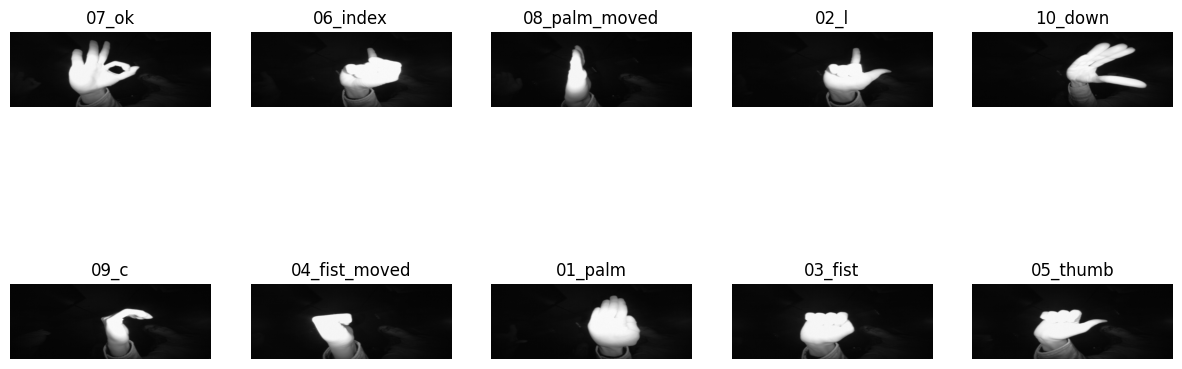

In [9]:
import matplotlib.pyplot as plt
import cv2
import os

base = "/content/leapGestRecog/00"

gestures = os.listdir(base)

plt.figure(figsize=(15,6))

for i, gesture in enumerate(gestures):

    folder = os.path.join(base, gesture)

    image = os.listdir(folder)[0]

    img = cv2.imread(os.path.join(folder, image))

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,5,i+1)

    plt.imshow(img)

    plt.title(gesture)

    plt.axis("off")

plt.show()

In [10]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical

In [11]:
dataset_path = "/content/leapGestRecog"

X = []
y = []

gesture_names = sorted(os.listdir(os.path.join(dataset_path, "00")))

label_map = {}

for idx, gesture in enumerate(gesture_names):
    label_map[idx] = gesture

for person in os.listdir(dataset_path):

    person_path = os.path.join(dataset_path, person)

    if not os.path.isdir(person_path):
        continue

    for label, gesture in enumerate(gesture_names):

        gesture_path = os.path.join(person_path, gesture)

        for image in os.listdir(gesture_path):

            img_path = os.path.join(gesture_path, image)

            img = cv2.imread(img_path)

            if img is None:
                continue

            img = cv2.resize(img, (64,64))

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            X.append(img)

            y.append(label)

X = np.array(X)

y = np.array(y)

print("Total Images :", len(X))

Total Images : 20000


In [12]:
X = X.astype("float32") / 255.0

In [13]:
y = to_categorical(y)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation="relu",input_shape=(64,64,3)))
model.add(MaxPooling2D())

model.add(Conv2D(64,(3,3),activation="relu"))
model.add(MaxPooling2D())

model.add(Conv2D(128,(3,3),activation="relu"))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(256,activation="relu"))

model.add(Dropout(0.5))

model.add(Dense(10,activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,275,722 (4.87 MB)

 Trainable params: 1,275,722 (4.87 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 60s 146ms/step - accuracy: 0.8835 - loss: 0.3479 - val_accuracy: 0.9997 - val_loss: 0.0040
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 56s 139ms/step - accuracy: 0.9924 - loss: 0.0260 - val_accuracy: 0.9978 - val_loss: 0.0044
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 84s 145ms/step - accuracy: 0.9945 - loss: 0.0187 - val_accuracy: 1.0000 - val_loss: 1.0165e-04
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 81s 142ms/step - accuracy: 0.9939 - loss: 0.0190 - val_accuracy: 1.0000 - val_loss: 2.9009e-04
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 55s 137ms/step - accuracy: 0.9967 - loss: 0.0111 - val_accuracy: 1.0000 - val_loss: 7.0754e-04
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 82s 138ms/step - accuracy: 0.9973 - loss: 0.0077 - val_accuracy: 0.9994 - val_loss: 0.0022
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 56s 141ms/step - accuracy: 0.9973 - loss: 0.0094 - val_accuracy: 1.0000 - val_loss: 1.0401e-04
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 81s 138ms/step - accuracy: 

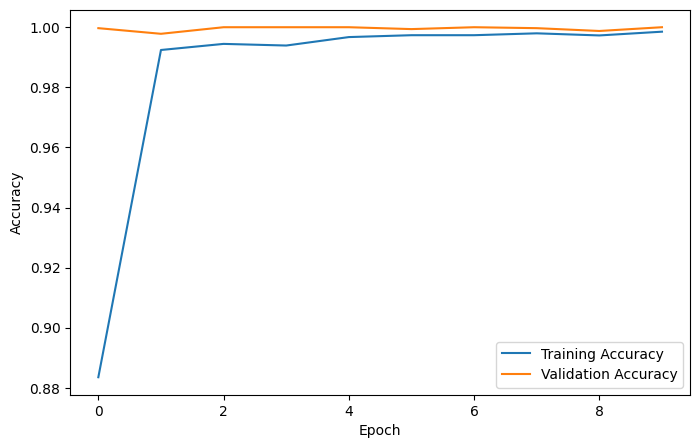

In [19]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"],label="Training Accuracy")

plt.plot(history.history["val_accuracy"],label="Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

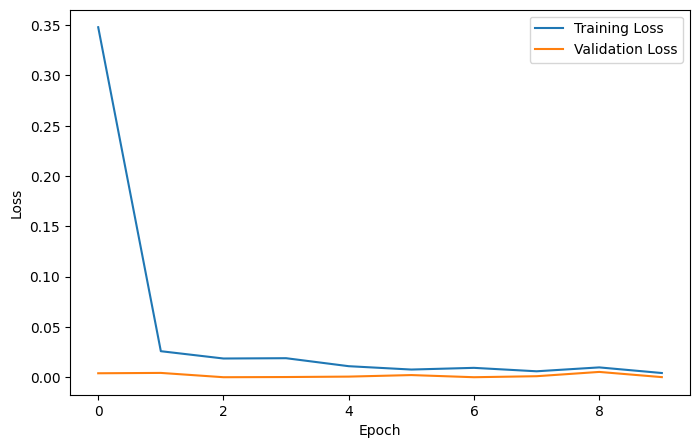

In [20]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"],label="Training Loss")

plt.plot(history.history["val_loss"],label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [21]:
loss,accuracy = model.evaluate(X_test,y_test)

print("Test Accuracy :",round(accuracy*100,2),"%")

125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.9992 - loss: 0.0023
Test Accuracy : 99.92 %


In [22]:
y_pred = model.predict(X_test)

y_pred = np.argmax(y_pred,axis=1)

y_true = np.argmax(y_test,axis=1)

125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step


In [23]:
print(classification_report(
    y_true,
    y_pred,
    target_names=gesture_names
))

               precision    recall  f1-score   support

      01_palm       1.00      1.00      1.00       400
         02_l       1.00      1.00      1.00       400
      03_fist       1.00      1.00      1.00       400
04_fist_moved       1.00      1.00      1.00       400
     05_thumb       1.00      1.00      1.00       400
     06_index       1.00      1.00      1.00       400
        07_ok       1.00      1.00      1.00       400
08_palm_moved       1.00      1.00      1.00       400
         09_c       1.00      1.00      1.00       400
      10_down       1.00      0.99      1.00       400

     accuracy                           1.00      4000
    macro avg       1.00      1.00      1.00      4000
 weighted avg       1.00      1.00      1.00      4000



<Figure size 1000x1000 with 0 Axes>

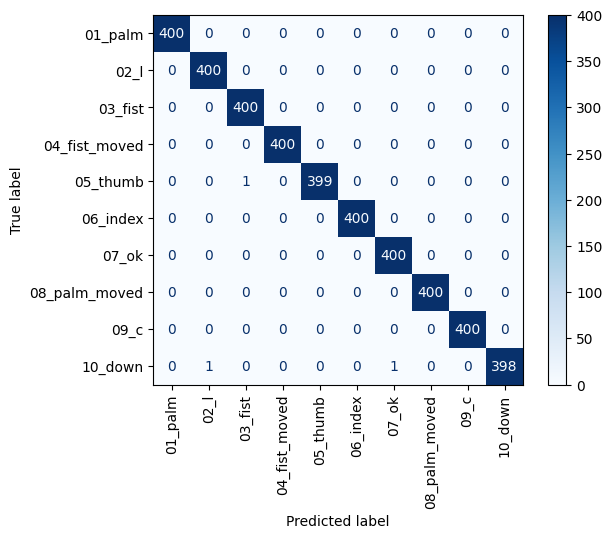

In [24]:
cm = confusion_matrix(y_true,y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=gesture_names
)

plt.figure(figsize=(10,10))

disp.plot(cmap="Blues",xticks_rotation=90)

plt.show()

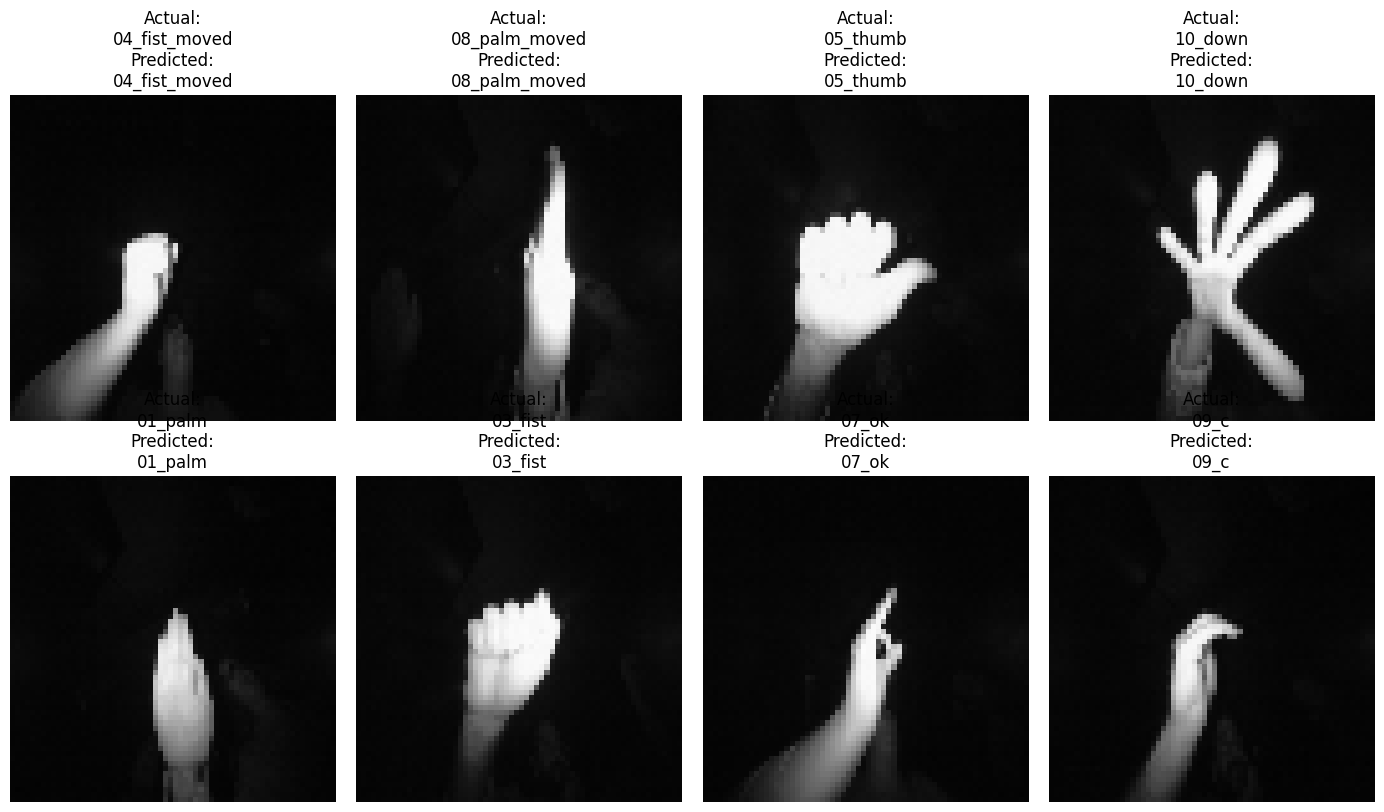

In [25]:
plt.figure(figsize=(14,8))

for i in range(8):

    plt.subplot(2,4,i+1)

    plt.imshow(X_test[i])

    actual = gesture_names[y_true[i]]

    predicted = gesture_names[y_pred[i]]

    plt.title(f"Actual:\n{actual}\nPredicted:\n{predicted}")

    plt.axis("off")

plt.tight_layout()

plt.show()

In [26]:
model.save("HandGestureCNN.h5")

print("Model Saved Successfully!")

Model Saved Successfully!
